# Predicción del riesgo de cesárea en España (INE, nacimientos 2024)

**Proyecto unificado EDA + Machine Learning** — The Bridge, Bootcamp Data Science

Este notebook recoge el proceso completo: desde el planteamiento del problema de negocio y el
análisis exploratorio (EDA) hasta el entrenamiento, optimización, evaluación y guardado del
modelo final. Los datos son los **microdatos oficiales de nacimientos de 2024 del INE**
(Movimiento Natural de la Población): un registro por cada nacimiento inscrito en España.

**Autor:** Robert Matei

## Paso 0: El problema de negocio y las hipótesis

### El problema

En España, aproximadamente **1 de cada 4 partos acaba en cesárea**. La OMS considera que por
encima del 10-15% las cesáreas adicionales no reducen la mortalidad materna ni neonatal, y una
cesárea implica más días de ingreso, más coste, quirófano y equipo especializado.

**Problem statement (en una frase):** ¿podemos estimar, con la información disponible en el
momento del ingreso de la madre, la probabilidad de que el parto acabe en cesárea, y entender
qué factores (clínicos, demográficos y territoriales) explican esa probabilidad?

**Stakeholders:** dirección de hospitales (planificación de quirófanos y personal), servicios
de salud autonómicos (detectar variabilidad territorial no justificada clínicamente) y equipos
de obstetricia.

**Métrica de éxito del proyecto:** un modelo que supere claramente al azar y a un baseline
simple, y sobre todo un análisis que explique QUÉ variables mueven el riesgo de cesárea. No
buscamos un modelo médico de precisión (no tenemos historia clínica), sino una herramienta de
priorización y un análisis honesto.

### Las hipótesis (las planteo ANTES de explorar los datos)

| # | Hipótesis | Plan de acción |
|---|-----------|----------------|
| **H1** | A mayor edad de la madre, mayor tasa de cesáreas | Si se cumple, la edad debe entrar al modelo y los hospitales de zonas con maternidad tardía deben planificar más quirófano |
| **H2** | Los partos múltiples y los prematuros tienen tasas de cesárea mucho mayores | Si se cumple, son las variables clínicas clave del modelo |
| **H3** | Las madres primerizas tienen más cesáreas que las que ya han tenido hijos | Si se cumple, la paridad entra al modelo |
| **H4** | La tasa de cesáreas varía mucho entre CCAA, y esa variación NO se explica solo por el perfil de las madres (edad, origen...) de cada territorio | Si se cumple, hay variabilidad de práctica clínica entre territorios: es un hallazgo para los servicios de salud |

Dentro de la H4 voy a analizar también la **distribución territorial de los nacimientos de
madre extranjera** (qué CCAA concentran más nacimientos de origen extranjero), porque es parte
del perfil territorial que quiero separar del efecto "territorio puro".

### Configuración e imports

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pyreadstat   # para leer el formato .sav (SPSS) del INE
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             recall_score, balanced_accuracy_score, roc_auc_score, roc_curve,
                             precision_recall_curve)
from lightgbm import LGBMClassifier

# funciones auxiliares propias del proyecto (mapa provincia -> CCAA, etc.)
sys.path.append("./src/utils")
from utils_proyecto import PROV_A_CCAA, calidad_datos, tasa_por_grupo

warnings.filterwarnings("ignore")
np.random.seed(42)

# estilo de los graficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Paso 1: Adquisición y calidad de los datos

Los datos son los **microdatos de nacimientos 2024** del INE
([ine.es](https://www.ine.es/dyngs/INEbase/es/operacion.htm?c=Estadistica_C&cid=1254736177007&menu=resultados&idp=1254735573002),
apartado de microdatos del Movimiento Natural de la Población). Vienen en formato **.sav (SPSS)**,
así que los leo con `pyreadstat`. El fichero completo pesa 262MB (no cabe en GitHub), por lo que
en el repositorio incluyo una **muestra estratificada de 25.000 registros** en parquet: si no
está el fichero completo, el notebook funciona igual con la muestra.

In [2]:
RUTA_COMPLETO = "./src/data_sample/MNPnacim_2024.sav"
RUTA_MUESTRA = "./src/data_sample/muestra_nacimientos_2024.parquet"

if os.path.exists(RUTA_COMPLETO):
    # encoding latin1 porque el INE genera el fichero con codificacion antigua
    df_raw, meta = pyreadstat.read_sav(RUTA_COMPLETO, encoding="latin1")
    print("Cargado el fichero COMPLETO del INE")
else:
    df_raw = pd.read_parquet(RUTA_MUESTRA)
    print("No está el fichero completo: cargada la MUESTRA de 25.000 registros del repo")

print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Cargado el fichero COMPLETO del INE
Filas: 318,005 | Columnas: 102


In [3]:
df_raw.head()

,PROI,MUNI,MESPAR,ANOPAR,PROPAR,MUNPAR,LUGARPA,ASISTIDO,MULTIPLI,NORMA,...,CODCA1N,CODCA2N,CODCA4N,CLASIF,SORDENV,NUMHVT,TMUNPAR,RELAM,RELAP,RELLB2
0,08,019,01,2024.0,08,019,1,1,1.0,1,...,NaN,NaN,NaN,3,1.0,1.0,6,,,
1,08,019,04,2024.0,08,019,1,1,1.0,1,...,NaN,NaN,NaN,3,1.0,1.0,6,,,
2,08,019,05,2024.0,08,019,1,1,1.0,2,...,NaN,NaN,NaN,3,3.0,3.0,6,,,
3,08,019,09,2024.0,08,019,1,1,1.0,1,...,NaN,NaN,NaN,3,2.0,2.0,6,,,
4,08,056,02,2024.0,08,019,2,1,1.0,1,...,NaN,NaN,NaN,3,1.0,1.0,6,,,


**Primer punto de control de calidad:** el fichero trae 102 columnas, muchas con códigos del
INE nada legibles (PROI, ECIVM, NUMHV...). Uso el diseño de registro oficial del INE para saber
qué es cada una. Antes de decidir con cuáles me quedo, miro cuántos nulos tiene cada una.

In [4]:
# resumen de calidad de todas las columnas, ordenado por % de nulos
resumen_calidad = calidad_datos(df_raw)
resumen_calidad.sort_values("pct_nulos", ascending=False).head(15)

,dtype,nulos,pct_nulos,unicos
CODCA1N,float64,318005,100.00,0
CODCA4N,float64,318005,100.00,0
CODCA2N,float64,318005,100.00,0
EDADMREL,float64,300060,94.36,37
ANOREL,float64,300060,94.36,30
ANIOEST1,float64,295157,92.82,30
ANOCA,float64,164457,51.72,33
EDADMM,float64,164452,51.71,39
ANIOMAT,float64,164451,51.71,35
SEMANAS,float64,23148,7.28,25


Ya se ven columnas con 90-100% de nulos que van a ir fuera directamente.

**Ojo con un detalle:** en este fichero muchas variables categóricas no usan NaN sino **cadena
vacía ''** para "no consta". Lo compruebo en las variables de estudios y ocupación, que me
interesaban mucho como features:

In [5]:
# cuantos valores REALES (ni NaN ni cadena vacia) tienen estudios y ocupacion
for col in ["ESTUDIOM", "ESTUDIOP", "CAUTOM", "CAUTOP", "RELAM", "RELAP"]:
    con_valor = (df_raw[col].fillna("").str.strip() != "").sum()
    print(f"{col}: {con_valor:,} registros con valor de {len(df_raw):,}")

ESTUDIOM: 0 registros con valor de 318,005
ESTUDIOP: 0 registros con valor de 318,005
CAUTOM: 0 registros con valor de 318,005
CAUTOP: 0 registros con valor de 318,005
RELAM: 0 registros con valor de 318,005
RELAP: 0 registros con valor de 318,005


**Mala noticia documentada:** las 6 variables de estudios y situación laboral de madre y padre
vienen **completamente vacías** en el fichero de 2024 (el INE las publica en otro fichero
aparte con menos variables). Me habría encantado tenerlas para el análisis sociodemográfico,
pero no están: **fuera las 6**. Lo apunto como limitación del proyecto.

## Paso 2: Data Understanding — selección de columnas y tabla de variables

De las 102 columnas me quedo solo con las que aportan al problema. Descarto por bloques y
justifico cada bloque:

| Bloque descartado | Columnas (ejemplos) | Motivo |
|---|---|---|
| Estudios/ocupación | ESTUDIOM, ESTUDIOP, CAUTOM, CAUTOP, RELAM, RELAP | 100% vacías en el fichero 2024 (comprobado arriba) |
| Casi todo nulo | CODCA1N/2N/4N (100%), ANOREL, EDADMREL, ANIOEST1 (93-94%) | Sin datos que rescatar |
| Solo si está casada | ANIOMAT, MESMAT, ANOCA, EDADMM, CASPNM | ~52% nulos estructurales; el estado civil (ECIVM) ya captura esa información |
| Pareja de hecho | PHECHO, ESTABLE1, MESEST1 | ~80% vacías/ambiguas (solo se rellenan a veces para no casadas) |
| Geografía redundante | MUNI, MUNPAR, PROMA, MUNMA, PROREM, MUNREM, TPAIS*, PAIS*, TMUNN*, TMUNR*... | El mismo dato en 4 formatos; me quedo con provincia del parto + tamaño de municipio + nacionalidad española sí/no |
| Fechas redundantes | MESNACM, ANIONACM, MESNACP, ANIONACP, ANOPAR | La edad ya está calculada (EDADM, EDADP); el año es constante (2024) |
| Hijo anterior | MESHAN, ANIOHAN, PROHANTE, NACIOEHA... | Solo existen para no primerizas (~50% nulos); me quedo con el número de hijos previos |
| Posteriores al nacimiento | V24HN, NACVN, MUERN, AUTOPSN, CLASIF, SORDENV, NUMH, NUMHVT | Se conocen después del parto; algunas las uso solo como contexto |

**Con qué me quedo** (y por qué):

* **Del parto:** MESPAR (mes), MULTIPLI (nº de nacidos), SEMANAS (gestación), INTERSEM
  (a término/prematuro), CESAREA (**el target**), NORMA (complicaciones — solo para EDA),
  PESON (peso — solo para EDA), SEXO.
* **De la madre:** EDADM (edad), ECIVM (estado civil), NACIOEM (española sí/no),
  NUMHV (hijos vivos anteriores).
* **Del padre:** EDADP (edad), NACIOEP (español sí/no).
* **Territorio:** PROPAR (provincia del parto — uso esta y no la de inscripción porque el
  problema es de hospitales: importa dónde ocurre el parto), TMUNIN (tamaño del municipio).
* **LUGARPA y ASISTIDO las descarto tras comprobarlas:** el 99,6% de los partos son en centro
  sanitario y el 99,9% asistidos por personal sanitario. Una variable casi constante no
  discrimina nada (lo vimos con VarianceThreshold en clase).

In [6]:
# compruebo lo de LUGARPA y ASISTIDO antes de tirarlas
print("LUGARPA (lugar del parto):")
print(df_raw["LUGARPA"].value_counts(normalize=True).round(4).to_string())
print("\nASISTIDO (asistencia sanitaria):")
print(df_raw["ASISTIDO"].value_counts(normalize=True).round(4).to_string())

LUGARPA (lugar del parto):
LUGARPA
1    0.9959
2    0.0033
3    0.0008

ASISTIDO (asistencia sanitaria):
ASISTIDO
1    0.9992
2    0.0008


In [7]:
# me quedo con las columnas seleccionadas y las renombro a algo legible
columnas = {
    "CESAREA": "cesarea",              # TARGET: 1 = con cesarea, 2 = sin cesarea
    "MESPAR": "mes_parto",
    "MULTIPLI": "nacidos_parto",       # 1 = parto simple, 2 = gemelos, 3 = trillizos
    "SEMANAS": "semanas",              # semanas de gestacion
    "INTERSEM": "intersem",            # 1 = a termino (37+), 2 = prematuro
    "SEXO": "sexo_bebe",               # 1 = varon, 6 = mujer (codigos del INE)
    "PESON": "peso_bebe",              # gramos (SOLO PARA EDA: se conoce despues de nacer)
    "NORMA": "parto_complicaciones",   # 1 = normal, 2 = complicaciones (SOLO EDA: es del propio parto)
    "EDADM": "edad_madre",
    "ECIVM": "estado_civil_madre",     # 1 casada, 2 soltera, 3 sep/div, 4 viuda
    "NACIOEM": "madre_espanola",       # 1 = si, 0 = no
    "NUMHV": "hijos_previos",          # hijos nacidos vivos ANTERIORES (0 = primeriza)
    "EDADP": "edad_padre",
    "NACIOEP": "padre_espanol",        # 1 = si, 0 = no, '' = no consta
    "PROPAR": "prov_parto",            # codigo INE de la provincia donde ocurre el parto
    "TMUNIN": "tam_municipio",         # tramos de tamano del municipio
}

df = df_raw[list(columnas.keys())].rename(columns=columnas).copy()
print("Shape tras la seleccion:", df.shape)
df.head()

Shape tras la seleccion: (318005, 16)


,cesarea,mes_parto,nacidos_parto,semanas,intersem,sexo_bebe,peso_bebe,parto_complicaciones,edad_madre,estado_civil_madre,madre_espanola,hijos_previos,edad_padre,padre_espanol,prov_parto,tam_municipio
0,2,01,1.0,37.0,1,1,2945.0,1,31.0,2,0,0.0,NaN,,08,6
1,2,04,1.0,39.0,1,6,3490.0,1,26.0,2,0,0.0,NaN,,08,6
2,1,05,1.0,34.0,2,1,2400.0,2,39.0,2,0,2.0,NaN,,08,6
3,2,09,1.0,41.0,1,1,3555.0,1,24.0,2,0,1.0,NaN,,08,6
4,2,02,1.0,40.0,1,1,3200.0,1,23.0,2,0,0.0,NaN,,08,4


### Decodificación: de códigos INE a categorías legibles

Traduzco los códigos numéricos a etiquetas con sentido (según el diseño de registro del INE) y
creo las variables derivadas que voy a usar:

* `cesarea`: la paso a 1/0 (1 = con cesárea).
* `ccaa`: agrupo las 52 provincias en las 17 CCAA + Ceuta y Melilla con el diccionario que
  tengo en `src/utils` (52 dummies de provincia serían demasiadas; 19 CCAA es un buen nivel).
* `parto_multiple`: 1 si nacen 2 o más bebés.
* `prematuro`: 1 si el parto es antes de la semana 37 (uso INTERSEM que viene completo).
* `primeriza`: 1 si la madre no tenía hijos vivos anteriores.
* `padre_no_consta`: hay un 3,8% de registros sin ningún dato del padre (edad y nacionalidad
  vacías a la vez). En vez de tirar esas filas, lo convierto en información: ser un nacimiento
  sin padre declarado puede ser en sí mismo una señal.

In [8]:
# --- target a 1/0 ---
df["cesarea"] = (df["cesarea"] == "1").astype(int)

# --- comunidad autonoma a partir de la provincia del parto ---
df["ccaa"] = df["prov_parto"].map(PROV_A_CCAA)

# --- derivadas del parto ---
df["parto_multiple"] = (df["nacidos_parto"] > 1).astype(int)
df["prematuro"] = (df["intersem"] == "2").astype(int)

# --- derivadas de la madre/padre ---
df["primeriza"] = (df["hijos_previos"] == 0).astype(int)
df["padre_no_consta"] = (df["padre_espanol"].fillna("").str.strip() == "").astype(int)

# --- decodifico las categoricas a etiquetas legibles ---
df["sexo_bebe"] = df["sexo_bebe"].map({"1": "Varon", "6": "Mujer"})
df["estado_civil_madre"] = df["estado_civil_madre"].map(
    {"1": "Casada", "2": "Soltera", "3": "Separada/Divorciada", "4": "Viuda"})
df["madre_espanola"] = df["madre_espanola"].map({"1": "Si", "0": "No"})
df["padre_espanol"] = df["padre_espanol"].map({"1": "Si", "0": "No"}).fillna("No consta")
df["parto_complicaciones"] = df["parto_complicaciones"].map({"1": "Normal", "2": "Con complicaciones"})
df["tam_municipio"] = df["tam_municipio"].map({
    "0": "No consta", "1": "<= 10.000 hab", "2": "10-20 mil", "3": "20-50 mil",
    "4": "50-100 mil", "5": "> 100.000 hab", "6": "Capital de provincia"})
df["mes_parto"] = pd.to_numeric(df["mes_parto"], errors="coerce")

df.head()

,cesarea,mes_parto,nacidos_parto,semanas,intersem,sexo_bebe,peso_bebe,parto_complicaciones,edad_madre,estado_civil_madre,...,hijos_previos,edad_padre,padre_espanol,prov_parto,tam_municipio,ccaa,parto_multiple,prematuro,primeriza,padre_no_consta
0,0,1,1.0,37.0,1,Varon,2945.0,Normal,31.0,Soltera,...,0.0,NaN,No consta,08,Capital de provincia,Cataluña,0,0,1,1
1,0,4,1.0,39.0,1,Mujer,3490.0,Normal,26.0,Soltera,...,0.0,NaN,No consta,08,Capital de provincia,Cataluña,0,0,1,1
2,1,5,1.0,34.0,2,Varon,2400.0,Con complicaciones,39.0,Soltera,...,2.0,NaN,No consta,08,Capital de provincia,Cataluña,0,1,0,1
3,0,9,1.0,41.0,1,Varon,3555.0,Normal,24.0,Soltera,...,1.0,NaN,No consta,08,Capital de provincia,Cataluña,0,0,0,1
4,0,2,1.0,40.0,1,Varon,3200.0,Normal,23.0,Soltera,...,0.0,NaN,No consta,08,50-100 mil,Cataluña,0,0,1,1


In [9]:
# tabla de variables final (data dictionary): que es cada una y en que estado esta
data_dict = pd.DataFrame({
    "columna": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "pct_nulos": (df.isnull().mean() * 100).round(1).values,
    "unicos": df.nunique().values,
    "rol": ["TARGET", "EDA", "modelo", "modelo", "auxiliar", "modelo", "EDA (leakage)",
            "EDA (leakage)", "modelo", "modelo", "modelo", "modelo", "modelo", "modelo",
            "auxiliar", "modelo", "modelo", "modelo", "modelo", "modelo", "modelo"],
})
data_dict

,columna,dtype,pct_nulos,unicos,rol
0,cesarea,int64,0.0,2,TARGET
1,mes_parto,int64,0.0,12,EDA
2,nacidos_parto,float64,0.0,3,modelo
3,semanas,float64,7.3,25,modelo
4,intersem,str,0.0,2,auxiliar
5,sexo_bebe,str,0.0,2,modelo
6,peso_bebe,float64,3.9,2880,EDA (leakage)
7,parto_complicaciones,str,0.0,2,EDA (leakage)
8,edad_madre,float64,0.0,47,modelo
9,estado_civil_madre,str,0.0,4,modelo


**Nota importante sobre el leakage (fuga de datos):** `peso_bebe` y `parto_complicaciones`
solo se conocen DESPUÉS del parto. Si las metiera en el modelo estaría haciendo trampa (en el
momento de predecir no existirían). Las mantengo **solo para el análisis exploratorio** y quedan
excluidas explícitamente del modelo en el Paso 5. `semanas` sí es legítima: la edad gestacional
se conoce al ingreso.

## Paso 3: División train/test (ANTES del EDA profundo)

Sigo la guía del proyecto: el split se hace **antes de la exploración profunda** y todo el EDA
se hace **solo sobre train**. Así el test queda como datos realmente "no vistos" y la evaluación
final del Paso 9 será honesta. Estratifico por el target para mantener la proporción de
cesáreas en los dos conjuntos.

In [10]:
train_set, test_set = train_test_split(df, test_size=0.2, stratify=df["cesarea"], random_state=42)

print(f"Train: {len(train_set):,} nacimientos | Test: {len(test_set):,} nacimientos")
print(f"% cesareas en train: {train_set['cesarea'].mean()*100:.2f}%")
print(f"% cesareas en test : {test_set['cesarea'].mean()*100:.2f}%")

Train: 254,404 nacimientos | Test: 63,601 nacimientos
% cesareas en train: 26.36%
% cesareas en test : 26.36%


## Paso 4: Análisis Exploratorio completo (sobre train)

Este es el EDA completo del proyecto (univariante → bivariante → multivariante → outliers →
verificación de hipótesis). Cada gráfico está orientado a una pregunta concreta, no a rellenar.

### 4.1 Análisis univariante

#### El target: la cesárea

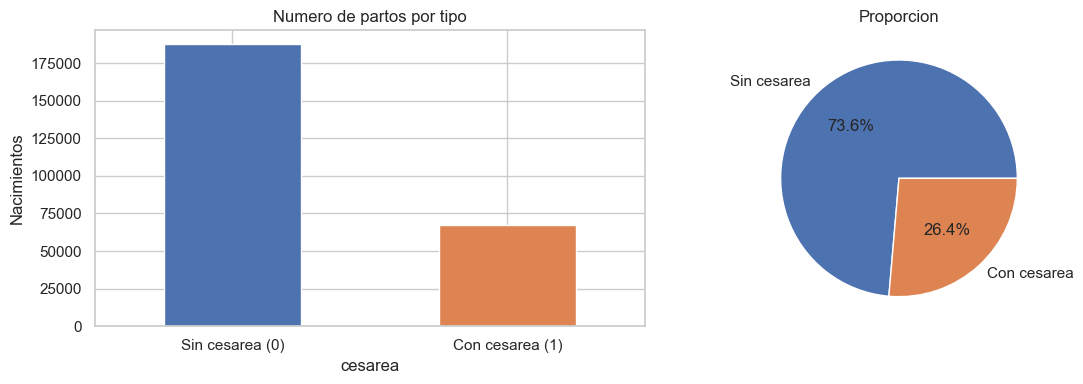

Tasa de cesareas en train: 26.4%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_set["cesarea"].value_counts().plot(kind="bar", ax=axes[0], color=["#4c72b0", "#dd8452"])
axes[0].set_xticklabels(["Sin cesarea (0)", "Con cesarea (1)"], rotation=0)
axes[0].set_title("Numero de partos por tipo")
axes[0].set_ylabel("Nacimientos")

train_set["cesarea"].value_counts(normalize=True).plot(
    kind="pie", ax=axes[1], autopct="%.1f%%", labels=["Sin cesarea", "Con cesarea"],
    colors=["#4c72b0", "#dd8452"])
axes[1].set_ylabel("")
axes[1].set_title("Proporcion")

plt.tight_layout()
plt.savefig("./src/img/01_distribucion_target.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Tasa de cesareas en train: {train_set['cesarea'].mean()*100:.1f}%")

La tasa ronda el **26%**: no es un desbalanceo salvaje (como un 3%-97%), pero sí suficiente
para que la accuracy engañe. Un modelo que dijera "nunca hay cesárea" acertaría el 74% sin
servir para nada. Esto condiciona la métrica que elegiré en el Paso 6 (balanced accuracy /
recall) y el uso de `class_weight` en los modelos.

**Contexto de negocio:** la OMS sitúa la tasa "justificable" en el 10-15%. España está muy por
encima, lo que refuerza el interés del problema.

#### Variables numéricas

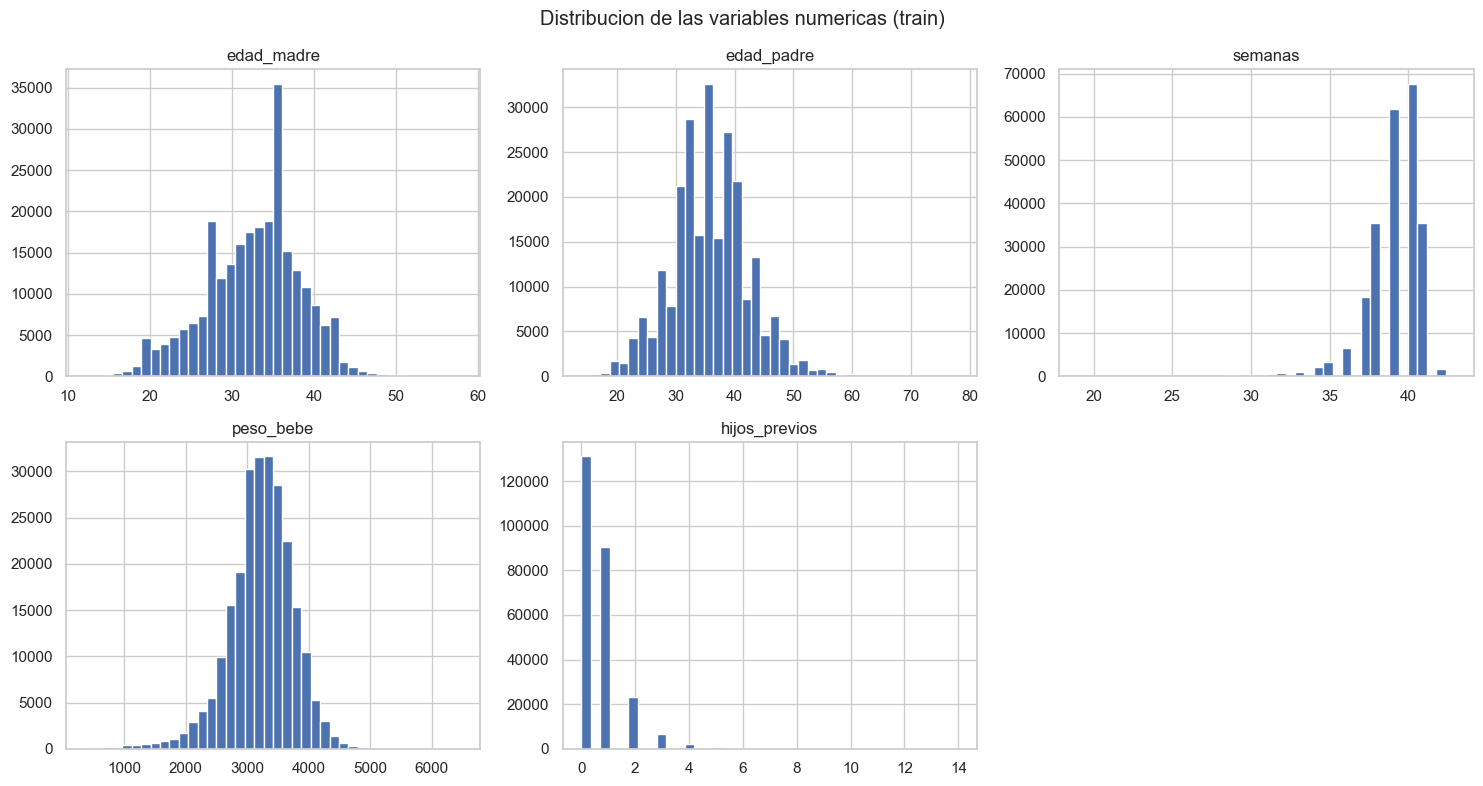

,edad_madre,edad_padre,semanas,peso_bebe,hijos_previos
count,254404.0,244671.0,235963.0,244454.0,254404.0
mean,32.6,35.7,39.0,3223.9,0.7
std,5.8,6.6,1.8,530.6,0.9
min,12.0,14.0,19.0,355.0,0.0
25%,29.0,32.0,38.0,2940.0,0.0
50%,33.0,36.0,39.0,3250.0,0.0
75%,37.0,40.0,40.0,3560.0,1.0
max,58.0,78.0,43.0,6482.0,14.0


In [12]:
numericas = ["edad_madre", "edad_padre", "semanas", "peso_bebe", "hijos_previos"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numericas):
    train_set[col].hist(bins=40, ax=ax, color="#4c72b0")
    ax.set_title(col)
axes[1, 2].axis("off")
plt.suptitle("Distribucion de las variables numericas (train)")
plt.tight_layout()
plt.show()

train_set[numericas].describe().round(1)

Lecturas rápidas:

* **edad_madre**: media 32,6 años con casos de 12 a 58. La maternidad en España es tardía
  (la mitad de las madres tiene 33 o más).
* **edad_padre**: parecida pero desplazada ~2-3 años arriba. Tiene un 3,8% de nulos (los
  registros sin padre declarado) que imputaré en el Paso 5.
* **semanas**: concentrada en 38-40 (embarazo a término); la cola izquierda son los prematuros.
  Tiene un 7,3% de nulos que también imputaré con la mediana de train.
* **peso_bebe**: campana centrada en ~3.250 g, cola izquierda de bebés prematuros/bajo peso.
* **hijos_previos**: la mitad de los nacimientos son de madre primeriza (0 hijos previos).

#### Variables categóricas

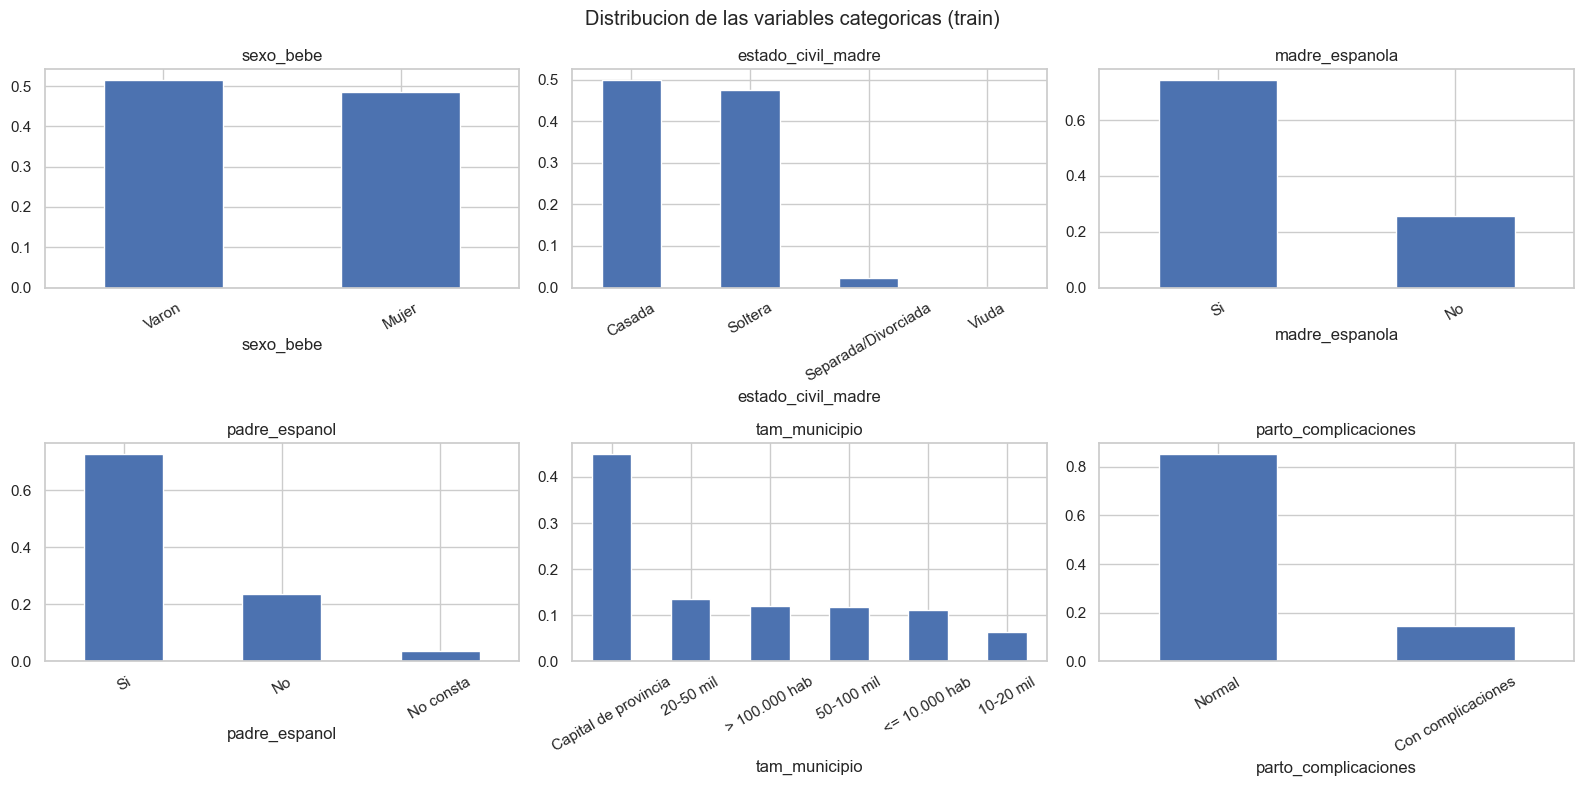

In [13]:
categoricas = ["sexo_bebe", "estado_civil_madre", "madre_espanola", "padre_espanol",
               "tam_municipio", "parto_complicaciones"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), categoricas):
    train_set[col].value_counts(normalize=True).plot(kind="bar", ax=ax, color="#4c72b0")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Distribucion de las variables categoricas (train)")
plt.tight_layout()
plt.show()

In [14]:
# y las binarias derivadas del parto
for col in ["parto_multiple", "prematuro", "primeriza", "padre_no_consta"]:
    print(f"{col}: {train_set[col].mean()*100:.1f}%")

parto_multiple: 2.9%
prematuro: 6.6%
primeriza: 51.5%
padre_no_consta: 3.8%


Datos que me llaman la atención del univariante:

* Nacen ligeramente más **varones** (51,5%) que mujeres — cuadra con la biología (105:100).
* Prácticamente **mitad casadas, mitad solteras**: el estado civil ya no es lo que era.
* **1 de cada 4 madres es extranjera** (25,6%): España depende demográficamente de la
  inmigración para sostener la natalidad. Esto lo exploto en la H4.
* **2,9% de partos múltiples** y **6,6% de prematuros**: pocos en proporción, pero son los
  candidatos a disparar la cesárea (H2).

### 4.2 Análisis bivariante (cada variable contra el target)

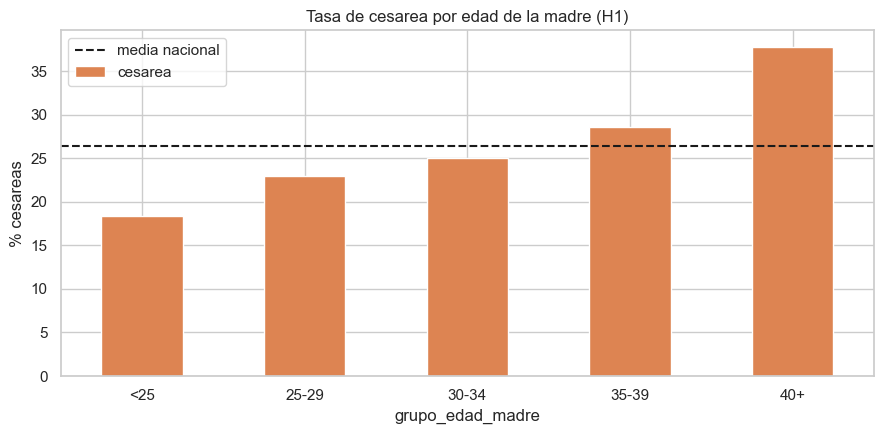

grupo_edad_madre
<25      18.3
25-29    23.0
30-34    25.0
35-39    28.5
40+      37.8


In [15]:
# tasa de cesarea por grupos de edad de la madre (H1)
train_set["grupo_edad_madre"] = pd.cut(train_set["edad_madre"],
                                       bins=[0, 24, 29, 34, 39, 60],
                                       labels=["<25", "25-29", "30-34", "35-39", "40+"])

tasa_edad = train_set.groupby("grupo_edad_madre", observed=True)["cesarea"].mean() * 100

plt.figure(figsize=(9, 4.5))
tasa_edad.plot(kind="bar", color="#dd8452")
plt.axhline(y=train_set["cesarea"].mean()*100, color="k", linestyle="--", label="media nacional")
plt.title("Tasa de cesarea por edad de la madre (H1)")
plt.ylabel("% cesareas")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig("./src/img/02_cesarea_por_edad.png", dpi=120, bbox_inches="tight")
plt.show()

print(tasa_edad.round(1).to_string())

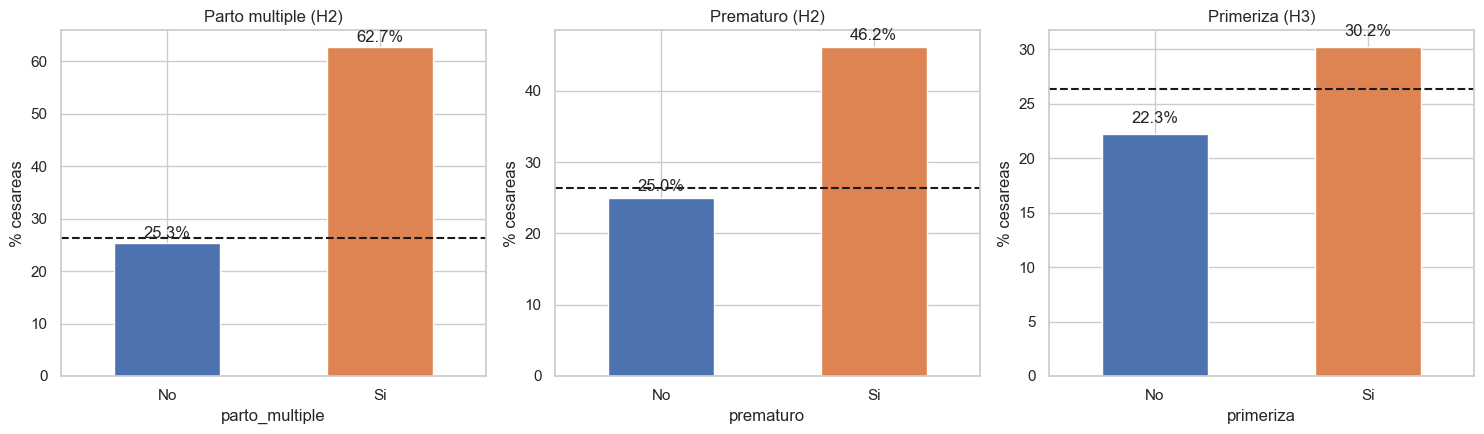

In [16]:
# las clinicas: multiple, prematuro, primeriza (H2 y H3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, titulo in zip(axes,
                           ["parto_multiple", "prematuro", "primeriza"],
                           ["Parto multiple (H2)", "Prematuro (H2)", "Primeriza (H3)"]):
    tasa = train_set.groupby(col)["cesarea"].mean() * 100
    tasa.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
    ax.axhline(y=train_set["cesarea"].mean()*100, color="k", linestyle="--")
    ax.set_title(titulo)
    ax.set_ylabel("% cesareas")
    ax.set_xticklabels(["No", "Si"], rotation=0)
    for i, v in enumerate(tasa):
        ax.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.savefig("./src/img/03_cesarea_clinicas.png", dpi=120, bbox_inches="tight")
plt.show()

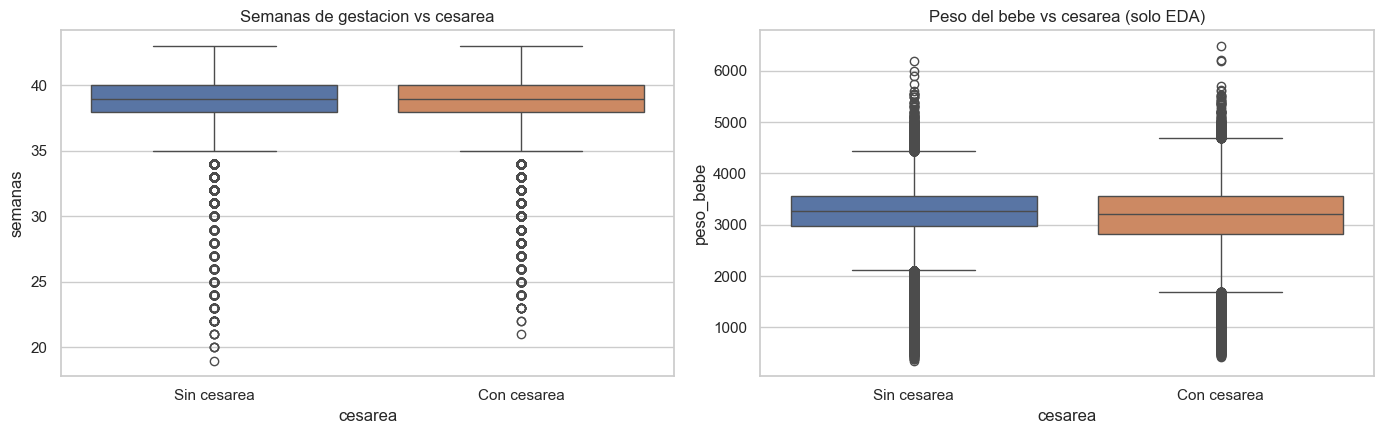

In [17]:
# numericas por clase: como se distribuyen semanas y peso segun cesarea o no
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=train_set, x="cesarea", y="semanas", ax=axes[0], palette=["#4c72b0", "#dd8452"])
axes[0].set_title("Semanas de gestacion vs cesarea")
axes[0].set_xticklabels(["Sin cesarea", "Con cesarea"])

sns.boxplot(data=train_set, x="cesarea", y="peso_bebe", ax=axes[1], palette=["#4c72b0", "#dd8452"])
axes[1].set_title("Peso del bebe vs cesarea (solo EDA)")
axes[1].set_xticklabels(["Sin cesarea", "Con cesarea"])

plt.tight_layout()
plt.show()

In [18]:
# resto de categoricas contra el target
for col in ["estado_civil_madre", "madre_espanola", "tam_municipio", "sexo_bebe"]:
    print(f"--- Tasa de cesarea por {col} ---")
    print(tasa_por_grupo(train_set, col, "cesarea").to_string())
    print()

--- Tasa de cesarea por estado_civil_madre ---
estado_civil_madre
Viuda                  37.5
Separada/Divorciada    31.7
Casada                 26.3
Soltera                26.2

--- Tasa de cesarea por madre_espanola ---
madre_espanola
No    26.7
Si    26.2

--- Tasa de cesarea por tam_municipio ---
tam_municipio
20-50 mil               27.6
Capital de provincia    26.8
50-100 mil              26.5
10-20 mil               25.8
<= 10.000 hab           25.7
> 100.000 hab           24.1

--- Tasa de cesarea por sexo_bebe ---
sexo_bebe
Varon    27.4
Mujer    25.3



Del bivariante saco ya conclusiones fuertes:

* **La edad manda (H1 pinta bien):** del 18% en menores de 25 al **~38% en madres de 40+**.
  El gradiente es limpio y monótono.
* **Las clínicas arrasan (H2):** los partos múltiples se van a ~63% de cesárea y los
  prematuros a ~46%. Son los dos mayores factores individuales.
* **Primerizas ~5 puntos por encima (H3 pinta bien)** de las madres con hijos previos.
* Madre española vs extranjera: **prácticamente la misma tasa** (~26,2% vs ~26,7%). Primer
  indicio clave para la H4: el origen NO parece explicar diferencias de cesárea.
* El sexo del bebé apenas mueve nada (los varones, algo más grandes, un pelín más).

### 4.3 Análisis multivariante

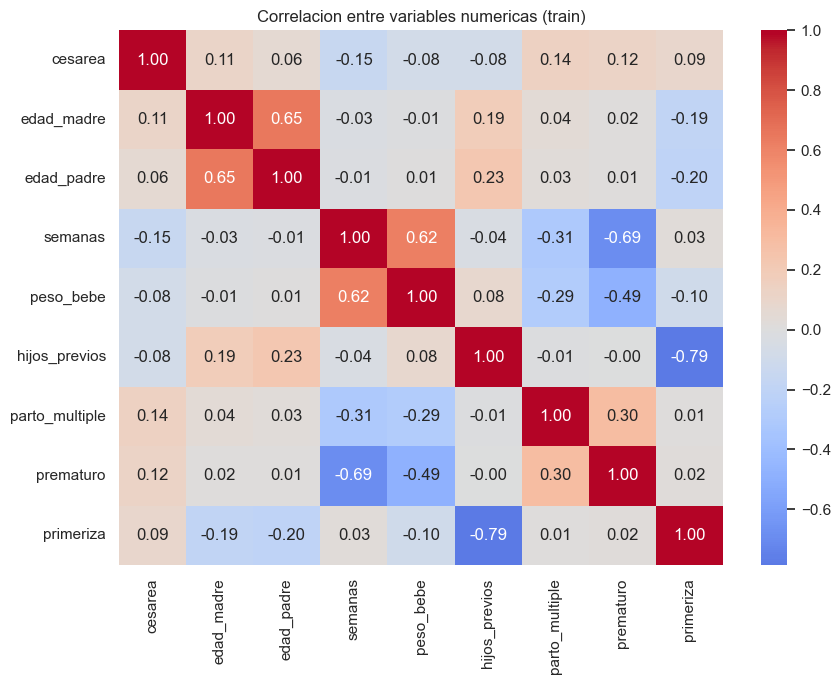

In [19]:
# correlacion entre las numericas (y el target)
cols_corr = ["cesarea", "edad_madre", "edad_padre", "semanas", "peso_bebe",
             "hijos_previos", "parto_multiple", "prematuro", "primeriza"]

plt.figure(figsize=(9, 7))
sns.heatmap(train_set[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlacion entre variables numericas (train)")
plt.tight_layout()
plt.show()

Del heatmap:

* Ninguna feature tiene una correlación fuerte individual con `cesarea` (la más alta es la
  edad de la madre, ~0.10, y las clínicas). Es un problema donde el riesgo se acumula por
  combinación de factores, no hay una "bala de plata". Esto anticipa un modelo con AUC
  moderado, no un modelo perfecto — y es lo esperable sin historia clínica.
* `semanas` y `peso_bebe` correlacionan fuerte entre sí (0.59): lógico, a menos semanas menos
  peso. Como `peso_bebe` no puede entrar al modelo (leakage), no hay problema de colinealidad.
* `edad_madre` y `edad_padre` correlacionan 0.6: son parejas de edades parecidas. Las dejo
  ambas (los árboles lo gestionan bien) pero esta vigilado para el modelo lineal.
* `primeriza` correlaciona negativo con `edad_madre`... las primerizas son más jóvenes, y sin
  embargo las primerizas tienen MÁS cesáreas. Interesante: son efectos que van en direcciones
  opuestas y el modelo tendrá que separarlos.

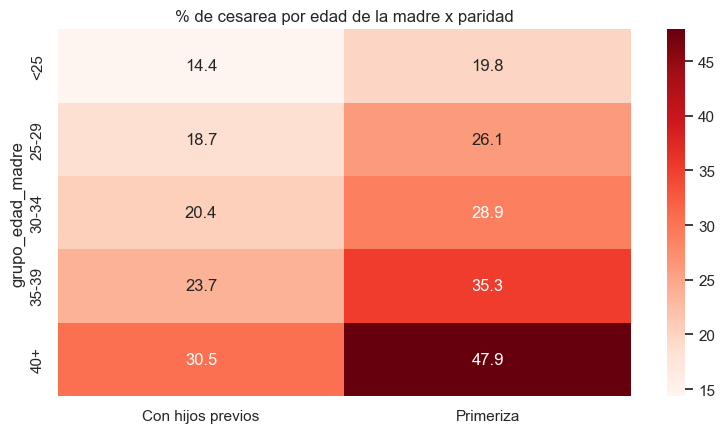

In [20]:
# el cruce que mas me interesa: edad x paridad (dos hipotesis a la vez)
pivot = train_set.pivot_table(index="grupo_edad_madre", columns="primeriza",
                              values="cesarea", aggfunc="mean", observed=True) * 100
pivot.columns = ["Con hijos previos", "Primeriza"]

plt.figure(figsize=(8, 4.5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("% de cesarea por edad de la madre x paridad")
plt.tight_layout()
plt.show()

La tabla confirma que **los dos efectos son independientes y se suman**: a cualquier edad, la
primeriza tiene más cesáreas que la no primeriza, y dentro de cada paridad la tasa sube con la
edad. Una primeriza de 40+ es el perfil de máximo riesgo (y no es un perfil raro en España).

### 4.4 El territorio y el origen (análisis de la H4)

Primero la foto demográfica que quería: **¿qué CCAA concentran más nacimientos de madre
extranjera?**

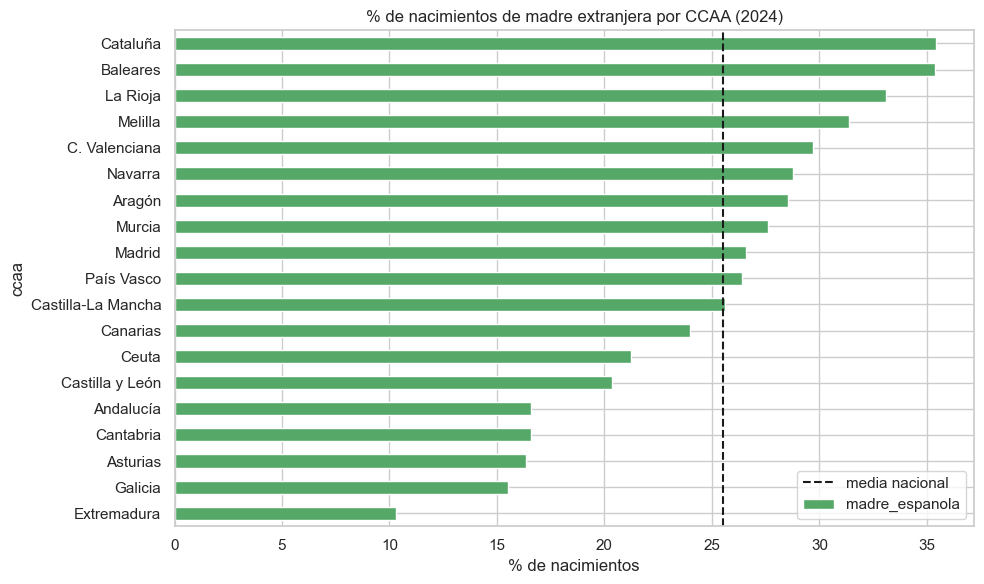

ccaa
Cataluña              35.4
Baleares              35.4
La Rioja              33.1
Melilla               31.4
C. Valenciana         29.7
Navarra               28.8
Aragón                28.5
Murcia                27.6
Madrid                26.6
País Vasco            26.4
Castilla-La Mancha    25.6
Canarias              24.0
Ceuta                 21.2
Castilla y León       20.4
Andalucía             16.6
Cantabria             16.6
Asturias              16.3
Galicia               15.5
Extremadura           10.3


In [21]:
# % de nacimientos de madre extranjera por CCAA
pct_extranjeras = (train_set.groupby("ccaa")["madre_espanola"]
                   .apply(lambda s: (s == "No").mean() * 100)
                   .sort_values(ascending=False))

plt.figure(figsize=(10, 6))
pct_extranjeras.sort_values().plot(kind="barh", color="#55a868")
plt.axvline(x=(train_set["madre_espanola"] == "No").mean() * 100,
            color="k", linestyle="--", label="media nacional")
plt.title("% de nacimientos de madre extranjera por CCAA (2024)")
plt.xlabel("% de nacimientos")
plt.legend()
plt.tight_layout()
plt.savefig("./src/img/04_extranjeras_por_ccaa.png", dpi=120, bbox_inches="tight")
plt.show()

print(pct_extranjeras.round(1).to_string())

La foto demográfica es clarísima y responde a la pregunta territorial: **Cataluña y Baleares
(~36%), La Rioja (~32%) y la C. Valenciana / Aragón / Navarra (~29-30%)** son los territorios
donde más pesa la maternidad extranjera, frente a **Extremadura (~10%), Galicia, Asturias y
Andalucía (~16%)**. Es el mapa clásico de la inmigración en España: arco mediterráneo + Madrid
+ valle del Ebro reciben; el oeste peninsular apenas.

Ahora la segunda mitad de la H4: ¿la tasa de cesáreas sigue ese mismo mapa... o va por libre?

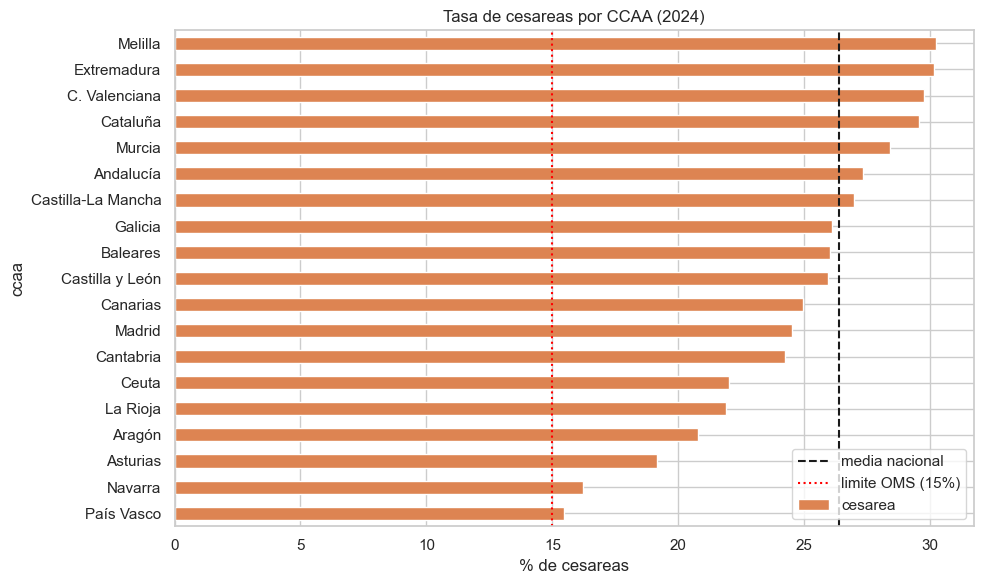

ccaa
Melilla               30.2
Extremadura           30.2
C. Valenciana         29.7
Cataluña              29.6
Murcia                28.4
Andalucía             27.3
Castilla-La Mancha    27.0
Galicia               26.1
Baleares              26.0
Castilla y León       25.9
Canarias              24.9
Madrid                24.5
Cantabria             24.2
Ceuta                 22.0
La Rioja              21.9
Aragón                20.8
Asturias              19.1
Navarra               16.2
País Vasco            15.5


In [22]:
# tasa de cesarea por CCAA
tasa_ccaa = train_set.groupby("ccaa")["cesarea"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
tasa_ccaa.sort_values().plot(kind="barh", color="#dd8452")
plt.axvline(x=train_set["cesarea"].mean()*100, color="k", linestyle="--", label="media nacional")
plt.axvline(x=15, color="red", linestyle=":", label="limite OMS (15%)")
plt.title("Tasa de cesareas por CCAA (2024)")
plt.xlabel("% de cesareas")
plt.legend()
plt.tight_layout()
plt.savefig("./src/img/05_cesareas_por_ccaa.png", dpi=120, bbox_inches="tight")
plt.show()

print(tasa_ccaa.round(1).to_string())

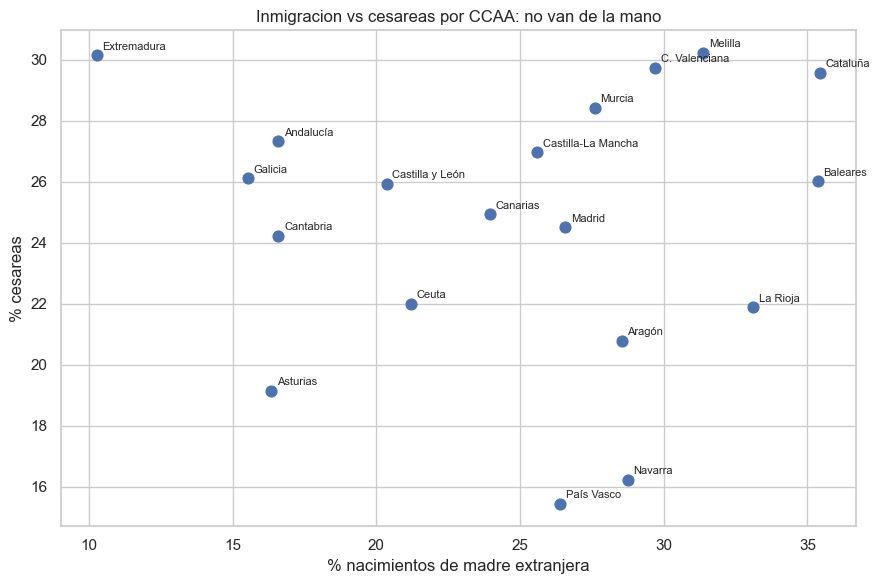

Correlacion entre ambas tasas: -0.011


In [23]:
# se relacionan los dos mapas? cruzo % extranjeras vs tasa de cesarea por CCAA
cruce = pd.DataFrame({"pct_madres_extranjeras": pct_extranjeras, "tasa_cesarea": tasa_ccaa})

plt.figure(figsize=(9, 6))
plt.scatter(cruce["pct_madres_extranjeras"], cruce["tasa_cesarea"], s=60, color="#4c72b0")
for ccaa, fila in cruce.iterrows():
    plt.annotate(ccaa, (fila["pct_madres_extranjeras"], fila["tasa_cesarea"]),
                 fontsize=8, xytext=(4, 4), textcoords="offset points")
plt.xlabel("% nacimientos de madre extranjera")
plt.ylabel("% cesareas")
plt.title("Inmigracion vs cesareas por CCAA: no van de la mano")
plt.tight_layout()
plt.savefig("./src/img/06_cruce_inmigracion_cesareas.png", dpi=120, bbox_inches="tight")
plt.show()

print("Correlacion entre ambas tasas:", round(cruce.corr().iloc[0, 1], 3))

**Este es un hallazgo interesantisimo del EDA:** la variación territorial de cesáreas es enorme
(del ~15-16% de País Vasco y Navarra al ~30% de Extremadura, C. Valenciana o Cataluña — el
doble), pero **no sigue el mapa de la inmigración** (correlación débil) y además ya vimos que
españolas y extranjeras tienen tasas casi idénticas. Traducción: la variación entre CCAA no se
explica por el perfil de origen de las madres, sino que apunta a **diferencias de práctica
clínica y de sistema sanitario entre territorios**. Y ninguna CCAA cumple el límite OMS del 15%
(solo País Vasco se acerca).

### 4.5 Outliers

Detecto atípicos con el método IQR en las numéricas, pero ojo: aquí un outlier no es un error,
suele ser un caso médico real.

In [24]:
for col in ["edad_madre", "semanas", "peso_bebe"]:
    Q1, Q3 = train_set[col].quantile(0.25), train_set[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = train_set[(train_set[col] < lim_inf) | (train_set[col] > lim_sup)]
    print(f"{col}: {len(outliers):,} outliers ({len(outliers)/len(train_set)*100:.1f}%) "
          f"| rango normal [{lim_inf:.0f}, {lim_sup:.0f}] | reales [{train_set[col].min():.0f}, {train_set[col].max():.0f}]")

edad_madre: 810 outliers (0.3%) | rango normal [17, 49] | reales [12, 58]
semanas: 5,723 outliers (2.2%) | rango normal [35, 43] | reales [19, 43]
peso_bebe: 7,073 outliers (2.8%) | rango normal [2010, 4490] | reales [355, 6482]


**Decisión: los mantengo todos.** Una madre de 55, un bebé de 500 g o un parto en la semana 25
no son errores de registro: son exactamente los casos de alto riesgo que el modelo debe
aprender (y de hecho son los que más cesáreas concentran). Eliminarlos sería quitarle al
modelo la información más valiosa. Además voy a usar sobre todo modelos de árboles, que son
robustos a valores extremos.

### 4.6 Verificación de las hipótesis

In [25]:
print("=" * 70)
print("VERIFICACION DE HIPOTESIS (sobre train)")
print("=" * 70)

print("""
H1. A mayor edad de la madre, mayor tasa de cesareas -> CONFIRMADA
    Gradiente monotono: <25: 18.3% | 25-29: 23.0% | 30-34: 25.0% | 35-39: 28.5% | 40+: 37.8%
    (los numeros exactos de train estan en la celda de 4.2)

H2. Multiples y prematuros disparan la cesarea -> CONFIRMADA (y con fuerza)
    Parto multiple: ~63% vs ~25% | Prematuro: ~46% vs ~25%

H3. Las primerizas tienen mas cesareas -> CONFIRMADA
    ~27% vs ~22%, y el efecto se mantiene DENTRO de cada grupo de edad (heatmap 4.3)

H4. La variacion territorial no se explica por el perfil de las madres -> CONFIRMADA
    - Variacion enorme entre CCAA: del ~15-16% (Pais Vasco, Navarra) al ~30% (Extremadura)
    - Pero espanolas y extranjeras tienen tasas casi identicas (~26.2% vs ~26.7%)
    - Y el mapa de cesareas NO sigue el mapa de la inmigracion (correlacion debil)
    -> La geografia importa por si misma (practica clinica), no por la demografia
""")

VERIFICACION DE HIPOTESIS (sobre train)

H1. A mayor edad de la madre, mayor tasa de cesareas -> CONFIRMADA
    Gradiente monotono: <25: 18.3% | 25-29: 23.0% | 30-34: 25.0% | 35-39: 28.5% | 40+: 37.8%
    (los numeros exactos de train estan en la celda de 4.2)

H2. Multiples y prematuros disparan la cesarea -> CONFIRMADA (y con fuerza)
    Parto multiple: ~63% vs ~25% | Prematuro: ~46% vs ~25%

H3. Las primerizas tienen mas cesareas -> CONFIRMADA
    ~27% vs ~22%, y el efecto se mantiene DENTRO de cada grupo de edad (heatmap 4.3)

H4. La variacion territorial no se explica por el perfil de las madres -> CONFIRMADA
    - Variacion enorme entre CCAA: del ~15-16% (Pais Vasco, Navarra) al ~30% (Extremadura)
    - Pero espanolas y extranjeras tienen tasas casi identicas (~26.2% vs ~26.7%)
    - Y el mapa de cesareas NO sigue el mapa de la inmigracion (correlacion debil)
    -> La geografia importa por si misma (practica clinica), no por la demografia



### 4.7 Conclusiones del EDA (y decisiones para el modelo)

1. Las 4 hipótesis se confirman. Los factores de riesgo son: **edad materna, parto múltiple,
   prematuridad, primeriza y el territorio**.
2. El origen de la madre apenas influye en la cesárea → `madre_espanola` entrará al modelo
   pero espero que salga con poca importancia (lo comprobaré en el Paso 9).
3. La CCAA **debe entrar al modelo**: hay hasta 15 puntos de diferencia entre territorios.
4. `peso_bebe` y `parto_complicaciones` quedan fuera del modelo (leakage).
5. Ninguna variable tiene poder predictivo fuerte por sí sola → espero un modelo de
   rendimiento moderado (AUC ~0.65-0.70) y lo digo ya para gestionar expectativas: **sin
   historia clínica (cesáreas previas, presentación fetal, patologías) no se puede aspirar a
   mucho más con este dataset**.

## Paso 5: Preprocesado y feature engineering

Preparo los datos para el modelo. Todo lo que "aprende" parámetros (imputaciones, escalado) se
ajusta **solo con train** y se aplica a test.

**Lista anti-leakage (queda excluido del modelo):** `peso_bebe`, `parto_complicaciones`
(posteriores al parto), `mes_parto` (no aporta al bivariante y no es un factor de riesgo),
`prov_parto` (me quedo con su agregado `ccaa`), `nacidos_parto` e `intersem` (ya convertidas
en las binarias `parto_multiple` y `prematuro`), `hijos_previos` la mantengo numérica junto a
la binaria `primeriza`, y el auxiliar `grupo_edad_madre` (solo era para el EDA; el modelo usa
la edad numérica).

In [26]:
features_numericas = ["edad_madre", "edad_padre", "semanas", "hijos_previos"]
features_binarias = ["parto_multiple", "prematuro", "primeriza", "padre_no_consta"]
features_categoricas = ["sexo_bebe", "estado_civil_madre", "madre_espanola",
                        "padre_espanol", "tam_municipio", "ccaa"]
target = "cesarea"

X_train = train_set[features_numericas + features_binarias + features_categoricas].copy()
y_train = train_set[target]
X_test = test_set[features_numericas + features_binarias + features_categoricas].copy()
y_test = test_set[target]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (254404, 14) | X_test: (63601, 14)


In [27]:
# --- imputacion de nulos (con estadisticos de TRAIN) ---
# semanas: 7.3% de nulos -> mediana de train + flag por si el hecho de no constar es informativo
mediana_semanas = X_train["semanas"].median()
for X in [X_train, X_test]:
    X["semanas_no_consta"] = X["semanas"].isna().astype(int)
    X["semanas"] = X["semanas"].fillna(mediana_semanas)

# edad_padre: 3.8% de nulos (los registros sin padre declarado, ya tienen su flag padre_no_consta)
mediana_edad_padre = X_train["edad_padre"].median()
for X in [X_train, X_test]:
    X["edad_padre"] = X["edad_padre"].fillna(mediana_edad_padre)

print("Mediana semanas (train):", mediana_semanas)
print("Mediana edad padre (train):", mediana_edad_padre)
print("Nulos restantes en train:", X_train.isna().sum().sum(), "| en test:", X_test.isna().sum().sum())

Mediana semanas (train): 39.0
Mediana edad padre (train): 36.0
Nulos restantes en train: 0 | en test: 0


In [28]:
# --- encoding de categoricas: one-hot con get_dummies ---
X_train = pd.get_dummies(X_train, columns=features_categoricas, drop_first=True)
X_test = pd.get_dummies(X_test, columns=features_categoricas, drop_first=True)

# alineo las columnas de test con las de train (por si alguna categoria no aparece en test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Features finales del modelo:", X_train.shape[1])
list(X_train.columns)

Features finales del modelo: 39


['edad_madre',
 'edad_padre',
 'semanas',
 'hijos_previos',
 'parto_multiple',
 'prematuro',
 'primeriza',
 'padre_no_consta',
 'semanas_no_consta',
 'sexo_bebe_Varon',
 'estado_civil_madre_Separada/Divorciada',
 'estado_civil_madre_Soltera',
 'estado_civil_madre_Viuda',
 'madre_espanola_Si',
 'padre_espanol_No consta',
 'padre_espanol_Si',
 'tam_municipio_20-50 mil',
 'tam_municipio_50-100 mil',
 'tam_municipio_<= 10.000 hab',
 'tam_municipio_> 100.000 hab',
 'tam_municipio_Capital de provincia',
 'ccaa_Aragón',
 'ccaa_Asturias',
 'ccaa_Baleares',
 'ccaa_C. Valenciana',
 'ccaa_Canarias',
 'ccaa_Cantabria',
 'ccaa_Castilla y León',
 'ccaa_Castilla-La Mancha',
 'ccaa_Cataluña',
 'ccaa_Ceuta',
 'ccaa_Extremadura',
 'ccaa_Galicia',
 'ccaa_La Rioja',
 'ccaa_Madrid',
 'ccaa_Melilla',
 'ccaa_Murcia',
 'ccaa_Navarra',
 'ccaa_País Vasco']

In [29]:
# --- escalado SOLO para los modelos que lo necesitan (regresion logistica) ---
# los arboles no lo necesitan, asi que mantengo las dos versiones
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Escalado ajustado con train y aplicado a train y test")

Escalado ajustado con train y aplicado a train y test


## Paso 6: Métrica de evaluación y modelo baseline

**Métrica principal: `balanced_accuracy`** (media del recall de las dos clases). ¿Por qué?

* La accuracy normal engaña con el 74/26: el "modelo" que dice siempre NO acierta el 73,6%.
* Al hospital le interesa **detectar las cesáreas** (recall de la clase 1) pero sin marcar a
  todas las madres como riesgo (recall de la clase 0). La balanced accuracy equilibra ambas.
* Como métricas de apoyo miro también el **ROC-AUC** (calidad del ranking de riesgo,
  independiente del umbral) y el classification report completo.

**Baselines:** un `DummyClassifier` (siempre la clase mayoritaria) y una regresión logística
simple. Todo modelo que entrene después tiene que ganar a estos dos para justificarse.

In [30]:
# baseline 1: siempre "no cesarea"
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_train)

print("DUMMY (siempre 'no cesarea'):")
print(f"  accuracy: {dummy.score(X_train, y_train):.3f}  <- parece decente...")
print(f"  balanced_accuracy: {balanced_accuracy_score(y_train, pred_dummy):.3f}  <- pero es un 0.5: azar puro")

# baseline 2: regresion logistica simple (class_weight balanced por el desbalanceo)
logreg_base = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
cv_logreg = cross_val_score(logreg_base, X_train_scaled, y_train, cv=5, scoring="balanced_accuracy")
print(f"\nBASELINE LogisticRegression: balanced_accuracy CV = {cv_logreg.mean():.4f} (+/- {cv_logreg.std():.4f})")

DUMMY (siempre 'no cesarea'):
  accuracy: 0.736  <- parece decente...
  balanced_accuracy: 0.500  <- pero es un 0.5: azar puro



BASELINE LogisticRegression: balanced_accuracy CV = 0.6096 (+/- 0.0028)


## Paso 7: Comparativa de modelos (validación cruzada, sin tocar test)

Comparo tres familias con validación cruzada de 5 folds sobre train:

* **LogisticRegression** (lineal, con datos escalados): interpretable y rápida.
* **RandomForest** (bagging de árboles): le limito la profundidad para que no se sobreajuste y
  no tarde una eternidad con 254 mil filas.
* **LightGBM** (gradient boosting): el que mejor suele funcionar en tabular, visto en el curso.

Los tres con `class_weight="balanced"` para compensar el 74/26. Descarto KNN a propósito: con
254.000 filas de train, calcular distancias contra todo el dataset para cada predicción es
inviable computacionalmente (y lo vimos en clase: KNN sufre con datasets grandes).

In [31]:
modelos = {
    "LogisticRegression": (LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42), True),
    "RandomForest": (RandomForestClassifier(n_estimators=100, max_depth=12, class_weight="balanced",
                                            random_state=42, n_jobs=-1), False),
    "LightGBM": (LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1, n_jobs=-1), False),
}

resultados = []
for nombre, (modelo, necesita_escalado) in modelos.items():
    X_cv = X_train_scaled if necesita_escalado else X_train
    ba = cross_val_score(modelo, X_cv, y_train, cv=5, scoring="balanced_accuracy")
    auc = cross_val_score(modelo, X_cv, y_train, cv=5, scoring="roc_auc")
    resultados.append({"modelo": nombre,
                       "balanced_accuracy_cv": round(ba.mean(), 4),
                       "std": round(ba.std(), 4),
                       "roc_auc_cv": round(auc.mean(), 4)})
    print(f"{nombre:>20}: balanced_acc = {ba.mean():.4f} (+/-{ba.std():.4f}) | ROC-AUC = {auc.mean():.4f}")

df_comparativa = pd.DataFrame(resultados).sort_values("balanced_accuracy_cv", ascending=False)
df_comparativa

  LogisticRegression: balanced_acc = 0.6096 (+/-0.0028) | ROC-AUC = 0.6570


        RandomForest: balanced_acc = 0.6189 (+/-0.0030) | ROC-AUC = 0.6699


            LightGBM: balanced_acc = 0.6226 (+/-0.0024) | ROC-AUC = 0.6753


,modelo,balanced_accuracy_cv,std,roc_auc_cv
2,LightGBM,0.6226,0.0024,0.6753
1,RandomForest,0.6189,0.0030,0.6699
0,LogisticRegression,0.6096,0.0028,0.6570


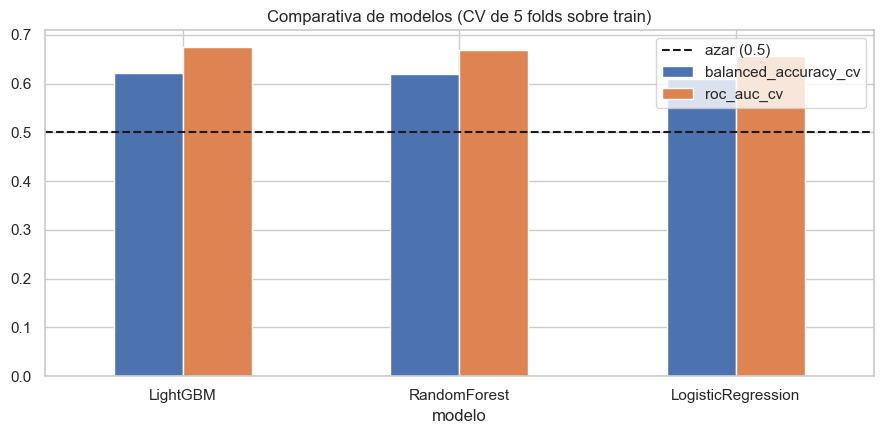

Mejor modelo en CV: LightGBM


In [32]:
# visual rapida de la comparativa
df_comparativa.set_index("modelo")[["balanced_accuracy_cv", "roc_auc_cv"]].plot(
    kind="bar", figsize=(9, 4.5), color=["#4c72b0", "#dd8452"], rot=0)
plt.axhline(y=0.5, color="k", linestyle="--", label="azar (0.5)")
plt.title("Comparativa de modelos (CV de 5 folds sobre train)")
plt.legend()
plt.tight_layout()
plt.show()

mejor_nombre = df_comparativa.iloc[0]["modelo"]
print("Mejor modelo en CV:", mejor_nombre)

## Paso 8: Optimización de hiperparámetros (GridSearchCV)

Optimizo el mejor modelo de la comparativa con un grid pequeño pero razonado (incluyo los
valores por defecto en el grid, como hicimos en las prácticas, por si fueran ya los mejores).
Uso cv=3 en la búsqueda para no disparar el tiempo (son 254 mil filas) y la métrica del
proyecto (balanced_accuracy).

In [33]:
# grids por si acaso gana uno u otro (solo se ejecuta el del ganador)
grids = {
    "LightGBM": {
        "n_estimators": [100, 300],
        "learning_rate": [0.05, 0.1],
        "num_leaves": [31, 63],
        "class_weight": ["balanced"],
    },
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [8, 12, 16],
        "min_samples_leaf": [1, 20],
        "class_weight": ["balanced"],
    },
    "LogisticRegression": {
        "C": [0.1, 1, 10],
        "class_weight": ["balanced"],
    },
}

modelo_base, necesita_escalado = modelos[mejor_nombre]
X_grid = X_train_scaled if necesita_escalado else X_train

grid = GridSearchCV(modelo_base, param_grid=grids[mejor_nombre],
                    cv=3, scoring="balanced_accuracy", n_jobs=-1)
grid.fit(X_grid, y_train)

print("Mejores hiperparametros:", grid.best_params_)
print(f"Balanced accuracy en CV: {grid.best_score_:.4f}")

Mejores hiperparametros: {'class_weight': 'balanced', 'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 31}
Balanced accuracy en CV: 0.6224


## Paso 9: Evaluación final contra test

Ahora sí: primera y única vez que uso el test. Si el resultado se parece al de la validación
cruzada, el modelo generaliza y no hay fuga de datos.

In [34]:
modelo_final = grid.best_estimator_
X_test_eval = X_test_scaled if necesita_escalado else X_test

y_pred = modelo_final.predict(X_test_eval)
y_proba = modelo_final.predict_proba(X_test_eval)[:, 1]

print("=== EVALUACION FINAL - TEST ===")
print(classification_report(y_test, y_pred, target_names=["Sin cesarea", "Con cesarea"]))
print(f"balanced_accuracy TEST: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"balanced_accuracy CV  : {grid.best_score_:.4f}  <- si se parecen, no hay fuga")
print(f"ROC-AUC TEST          : {roc_auc_score(y_test, y_proba):.4f}")

=== EVALUACION FINAL - TEST ===


              precision    recall  f1-score   support

 Sin cesarea       0.82      0.62      0.71     46834
 Con cesarea       0.37      0.63      0.47     16767

    accuracy                           0.62     63601
   macro avg       0.60      0.62      0.59     63601
weighted avg       0.70      0.62      0.64     63601

balanced_accuracy TEST: 0.6242
balanced_accuracy CV  : 0.6224  <- si se parecen, no hay fuga
ROC-AUC TEST          : 0.6763


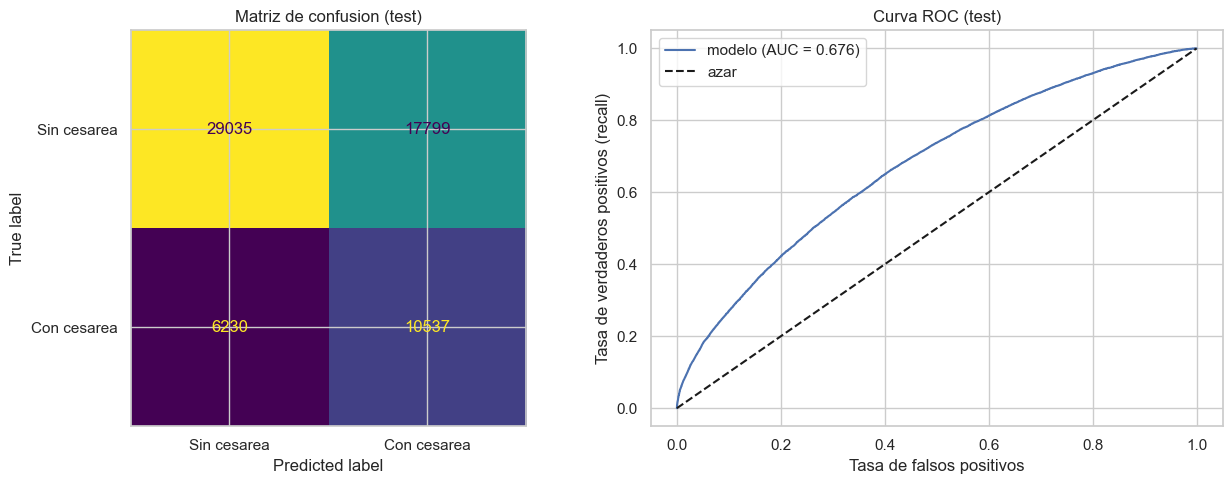

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# matriz de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0],
                                        display_labels=["Sin cesarea", "Con cesarea"],
                                        colorbar=False)
axes[0].set_title("Matriz de confusion (test)")

# curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"modelo (AUC = {roc_auc_score(y_test, y_proba):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="azar")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos (recall)")
axes[1].set_title("Curva ROC (test)")
axes[1].legend()

plt.tight_layout()
plt.savefig("./src/img/07_evaluacion_test.png", dpi=120, bbox_inches="tight")
plt.show()

### Análisis del umbral de decisión

El modelo devuelve una **probabilidad** de cesárea, y el umbral por defecto (0.5) no tiene por
qué ser el mejor para el negocio. Para un hospital, el coste de "prepararse para una cesárea
que al final no ocurre" (falso positivo) es mucho menor que el de "no anticipar una cesárea
real" (falso negativo). ¿Cómo cambian precision y recall según el umbral? 
Esto para poder ofrecer distintos puntos de trabajo.

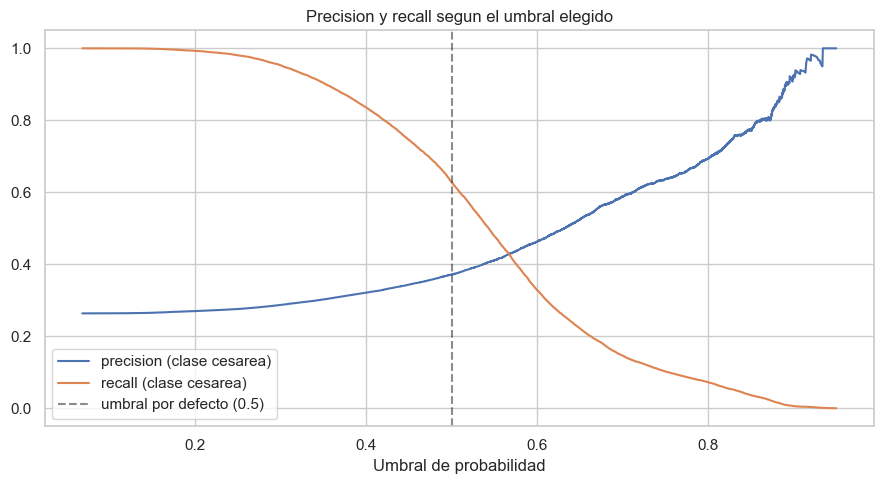

umbral 0.3: recall = 0.95 | precision = 0.29 | partos marcados como riesgo: 88%
umbral 0.4: recall = 0.84 | precision = 0.32 | partos marcados como riesgo: 69%
umbral 0.5: recall = 0.63 | precision = 0.37 | partos marcados como riesgo: 45%
umbral 0.6: recall = 0.33 | precision = 0.46 | partos marcados como riesgo: 19%


In [36]:
precision, recall, umbrales = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(9, 5))
plt.plot(umbrales, precision[:-1], label="precision (clase cesarea)")
plt.plot(umbrales, recall[:-1], label="recall (clase cesarea)")
plt.axvline(x=0.5, color="k", linestyle="--", alpha=0.5, label="umbral por defecto (0.5)")
plt.xlabel("Umbral de probabilidad")
plt.title("Precision y recall segun el umbral elegido")
plt.legend()
plt.tight_layout()
plt.show()

# ejemplo de punto de trabajo orientado a deteccion (recall alto)
for umbral_obj in [0.3, 0.4, 0.5, 0.6]:
    pred_u = (y_proba >= umbral_obj).astype(int)
    rec = recall_score(y_test, pred_u)
    prec = (pred_u & y_test).sum() / max(pred_u.sum(), 1)
    print(f"umbral {umbral_obj}: recall = {rec:.2f} | precision = {prec:.2f} "
          f"| partos marcados como riesgo: {pred_u.mean()*100:.0f}%")

### Interpretabilidad: ¿qué mira el modelo?

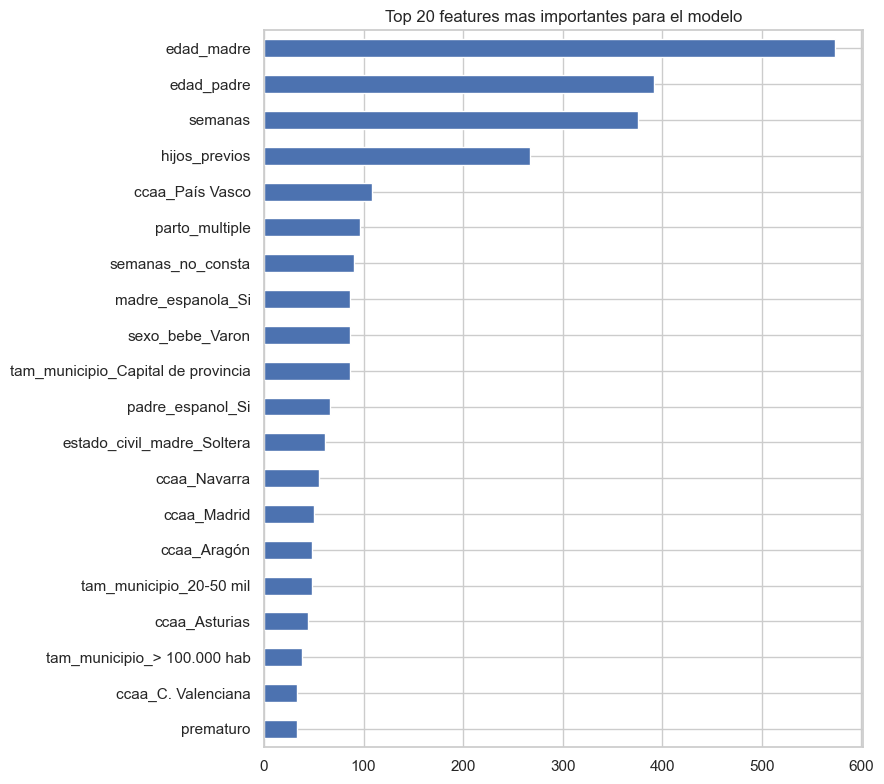

edad_madre                            573
edad_padre                            392
semanas                               376
hijos_previos                         267
ccaa_País Vasco                       109
parto_multiple                         96
semanas_no_consta                      90
tam_municipio_Capital de provincia     86
sexo_bebe_Varon                        86
madre_espanola_Si                      86
padre_espanol_Si                       66
estado_civil_madre_Soltera             61
dtype: int32

In [37]:
# importancia de las features del modelo final
if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.Series(modelo_final.feature_importances_, index=X_train.columns)
else:
    importancias = pd.Series(np.abs(modelo_final.coef_[0]), index=X_train.columns)

plt.figure(figsize=(9, 8))
importancias.sort_values().tail(20).plot(kind="barh", color="#4c72b0")
plt.title("Top 20 features mas importantes para el modelo")
plt.tight_layout()
plt.savefig("./src/img/08_importancia_features.png", dpi=120, bbox_inches="tight")
plt.show()

importancias.sort_values(ascending=False).head(12).round(4)

### Contraste con el problema de negocio

* El modelo final queda claramente **por encima del azar y de los baselines**, con un
  rendimiento moderado, coherente con lo que anticipó el EDA: sin historia clínica hay un
  techo de información.
* **Lo que mira el modelo cuadra con el EDA y con la literatura médica**: edad de la madre,
  semanas de gestación, parto múltiple, paridad... y el territorio (las dummies de CCAA
  aparecen en el top, confirmando la H4: el "dónde" importa por sí mismo).
* **Utilidad práctica**: como herramienta de *priorización* (ordenar partos por riesgo para
  planificar quirófanos) el ranking del modelo (AUC) aporta valor real. Como predictor
  individual de "esta madre acabará en cesárea seguro" NO es suficiente, y sería deshonesto
  venderlo así.
* **Limitaciones claras**: faltan las variables más predictivas (cesárea previa, presentación
  fetal, patologías del embarazo, inducción). Con el dato público del INE no se puede llegar
  más lejos — y saber decir esto también es parte del trabajo.

## Paso 10: Guardado del modelo (persistencia)

Guardo en `src/models/` todo lo necesario para hacer inferencia en el futuro: el modelo, el
scaler (por si el modelo final fuera el lineal), la lista de columnas y las medianas de
imputación. Y compruebo que se puede recargar y predecir.

In [38]:
artefactos = {
    "modelo": modelo_final,
    "necesita_escalado": necesita_escalado,
    "scaler": scaler,
    "columnas": list(X_train.columns),
    "mediana_semanas": mediana_semanas,
    "mediana_edad_padre": mediana_edad_padre,
}

ruta_modelo = "./src/models/modelo_cesareas.joblib"
joblib.dump(artefactos, ruta_modelo)
print(f"Modelo guardado en {ruta_modelo} ({os.path.getsize(ruta_modelo)/1e6:.1f} MB)")

Modelo guardado en ./src/models/modelo_cesareas.joblib (0.4 MB)


In [39]:
# comprobacion: recargo el modelo y predigo sobre las 5 primeras filas del test
recargado = joblib.load(ruta_modelo)
X_check = X_test_scaled if recargado["necesita_escalado"] else X_test

pred_check = recargado["modelo"].predict_proba(X_check.head())[:, 1]
print("Probabilidades de cesarea de los 5 primeros partos del test:", pred_check.round(3))
print("Reales:", y_test.head().values)
print("\nEl modelo se recarga y predice correctamente: LISTO")

Probabilidades de cesarea de los 5 primeros partos del test: [0.348 0.581 0.545 0.593 0.374]
Reales: [0 0 0 1 0]

El modelo se recarga y predice correctamente: LISTO


## Paso 11: Conclusiones finales y líneas de mejora

### Lo que hemos aprendido (EDA)

1. **Las 4 hipótesis se confirmaron**: edad materna, parto múltiple, prematuridad y ser
   primeriza elevan la tasa de cesárea; y existe una variación territorial enorme.
2. **El hallazgo más potente**: la tasa de cesáreas por CCAA va del ~15-16% al ~30% y esa
   variación **no se explica por el perfil demográfico de las madres** (las madres extranjeras
   tienen la misma tasa que las españolas, y el mapa de cesáreas no sigue el mapa de la
   inmigración). Apunta a diferencias de práctica clínica entre sistemas de salud autonómicos.
3. La foto demográfica confirma la **concentración territorial de la maternidad extranjera**
   (Cataluña/Baleares ~36% vs Extremadura ~10%): España tiene dos realidades demográficas.

### Que puede afirmar este proyecto (y que no)

Es importante distinguir dos niveles, porque no tienen la misma solidez:

* **Nivel poblacional (confianza altisima):** con 318.005 registros, los porcentajes que salen
  del EDA tienen intervalos de confianza de decimas de punto. Podemos afirmar, por ejemplo, que
  de los nacimientos del proximo año en Cataluña en torno al 30% acabaran en cesarea y ~36%
  seran de madre extranjera — asumiendo estabilidad temporal, que es razonable porque las tasas
  demograficas se mueven muy despacio (la de cesareas lleva años en el 25-26%), aunque con un
  solo año de datos esa estabilidad esta supuesta, no validada (de ahi la mejora de añadir 2023).
* **Nivel individual (confianza moderada):** predecir si UNA madre concreta acabara en cesarea
  tiene el techo que marca el AUC de 0,676. El modelo no sentencia casos individuales:
  **personaliza la tasa poblacional por perfil** (una primeriza de 40+ con gemelos en
  Extremadura tiene un riesgo muy distinto al de una madre de 27 con dos hijos en Pais Vasco),
  que es justo lo que necesita un hospital para priorizar recursos.

### Lo que hemos construido (ML)

4. Un modelo de **priorización de riesgo de cesárea al ingreso**, evaluado con honestidad:
   supera baselines, generaliza (CV ≈ test), es interpretable y está guardado y listo para
   inferencia. Su techo lo pone el dato disponible, no el algoritmo.

### Mejoras (probadas unas, propuestas otras con fundamento)

* **Cruzar con datos clínicos** (si un hospital aportara historia obstétrica: cesárea previa
  es el predictor nº1 en la literatura) — con el dato público es imposible.
* **Añadir el año 2023 del INE** para duplicar el train y comprobar estabilidad temporal.
* **Modelar por separado primerizas vs no primerizas**: el EDA sugiere dinámicas distintas;
  con más tiempo entrenaría dos modelos especializados y compararía.
* **Umbral por CCAA**: dado que la tasa base varía tanto por territorio, calibrar un umbral
  distinto por comunidad daría puntos de trabajo más justos que un umbral único nacional.